In [1]:
import os
import tarfile
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import transforms, models, datasets
from torchvision.datasets import ImageFolder
from PIL import Image
import pandas as pd



## Dataset Extraction: Decompressing `.tar.xz` Archives for Training and Testing


In [2]:


def extract_xz(file_path, extract_path):
    with tarfile.open(file_path) as tar:
        tar.extractall(path=extract_path)

extract_xz("/content/gnr_train.tar.xz", "data/train")
extract_xz("/content/gnr_test.tar.xz", "data/test")








/tmp/ipython-input-4085500803.py:3: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=extract_path)


## Test Dataset Class for Loading and Preprocessing Images


In [3]:


class TestDataset(Dataset):
    def __init__(self, root, transform=None):
        self.root = root
        self.transform = transform
        self.images = sorted(os.listdir(root))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]
        img_path = os.path.join(self.root, img_name)
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        image_id = os.path.splitext(img_name)[0]
        return image, image_id


## Training Data Pipeline: Transformations and DataLoader Setup


In [4]:


transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])

train_dataset = datasets.ImageFolder(
    root="data/train",
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

## Test Dataset and DataLoader Configuration


In [5]:
test_dataset = TestDataset(
    root="data/test",
    transform=transform
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)


## Class Label Mapping


In [6]:
class_to_label = {
    "Basketball court": 1,
    "Bridge": 2,
    "Crosswalk": 3,
    "Golfcourse": 4,
    "Oil well": 5,
    "Overpass": 6,
    "Railway": 7,
    "Runway": 8,
    "Swimming pool": 9,
    "Tennis court": 10
}


## Model Setup


In [7]:


device = "cuda" if torch.cuda.is_available() else "cpu"

model = models.resnet18(weights="IMAGENET1K_V1")
model.fc = nn.Linear(model.fc.in_features, 10)
model = model.to(device)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 226MB/s]


In [8]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)


## Training Procedure: Forward Pass, Backpropagation, and Accuracy Evaluation


In [9]:
from sklearn.metrics import accuracy_score

for epoch in range(10):
    model.train()
    running_loss = 0
    all_labels = []
    all_preds = []

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

    train_loss = running_loss / len(train_loader)
    train_acc = accuracy_score(all_labels, all_preds)

    print(f"Epoch {epoch+1} | Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")


Epoch 1 | Loss: 0.9532 | Train Acc: 0.9300
Epoch 2 | Loss: 0.2780 | Train Acc: 1.0000
Epoch 3 | Loss: 0.0964 | Train Acc: 1.0000
Epoch 4 | Loss: 0.0488 | Train Acc: 1.0000
Epoch 5 | Loss: 0.0310 | Train Acc: 1.0000
Epoch 6 | Loss: 0.0224 | Train Acc: 1.0000
Epoch 7 | Loss: 0.0175 | Train Acc: 1.0000
Epoch 8 | Loss: 0.0139 | Train Acc: 1.0000
Epoch 9 | Loss: 0.0116 | Train Acc: 1.0000
Epoch 10 | Loss: 0.0099 | Train Acc: 1.0000


## Inference Pipeline: Predicting Test Labels and Creating Submission File


In [10]:
model.eval()
test_preds = []
image_ids = []

with torch.no_grad():
    for images, ids in test_loader:
        images = images.to(device)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)
        test_preds.extend(preds.cpu().numpy())
        image_ids.extend(ids)

submission = pd.DataFrame({
    "ImageID": image_ids,
    "LabelID": [p+1 for p in test_preds]
})

submission.to_csv(" and import the fil,e the first column .csv", index=False)
print("Test predictions saved  ")


Test predictions saved  


['132.jpg', '102.jpg', '111.jpg', '126.jpg', '192.jpg', '109.jpg', '153.jpg', '104.jpg', '157.jpg', '160.jpg']


In [12]:
import os

print(os.listdir("data/test")[:10])

model.eval()
image_ids = []
predictions = []

with torch.no_grad():
    for images, ids in test_loader:
        images = images.to(device)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        predictions.extend(preds.cpu().numpy())
        image_ids.extend(ids)


## Submission File Generation: Saving Predicted Labels


In [13]:

submission = pd.DataFrame({
    "ImageID": image_ids,
    "LabelID": [p + 1 for p in predictions]
})


submission.to_csv("s1.csv", index=False)


## Alternative Model Architecture and Training Pipeline


In [14]:


device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)


Device: cuda


In [15]:


extract_xz("/content/gnr_train.tar.xz", "data/train")
extract_xz("/content/gnr_test.tar.xz", "data/test")


/tmp/ipython-input-4018053512.py:3: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=extract_path)


In [16]:
TRAIN_ROOT = "data/train/train"
TEST_ROOT  = "data/test"

print(os.listdir(TRAIN_ROOT))
print(os.listdir(TEST_ROOT)[:5])


['swimming_pool', 'oil_well', 'overpass', 'railway', 'runway', 'tennis_court', 'basketball_court', 'bridge', 'golf_course', 'crosswalk']
['132.jpg', '102.jpg', '111.jpg', '126.jpg', '192.jpg']


In [17]:
label_map = {
    "basketball_court": 1,
    "bridge": 2,
    "crosswalk": 3,
    "golf_course": 4,
    "oil_well": 5,
    "overpass": 6,
    "railway": 7,
    "runway": 8,
    "swimming_pool": 9,
    "tennis_court": 10
}


In [18]:


class SmartImageFolder(ImageFolder):
    def __init__(self, root, transform=None):
        super().__init__(root, transform)
        new_class_to_idx = {}
        for folder in self.classes:
            new_class_to_idx[folder] = label_map[folder] - 1
        self.class_to_idx = new_class_to_idx


In [19]:


train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor()
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])


In [20]:


train_dataset = SmartImageFolder(root=TRAIN_ROOT, transform=train_transform)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

print("Class mapping used:")
print(train_dataset.class_to_idx)


Class mapping used:
{'basketball_court': 0, 'bridge': 1, 'crosswalk': 2, 'golf_course': 3, 'oil_well': 4, 'overpass': 5, 'railway': 6, 'runway': 7, 'swimming_pool': 8, 'tennis_court': 9}


## Test Dataset Class and DataLoader Setup for New Model


In [21]:

class TestDataset(Dataset):
    def __init__(self, root, transform=None):
        self.root = root
        self.transform = transform
        self.images = sorted(os.listdir(root))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]
        img_path = os.path.join(self.root, img_name)
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        image_id = os.path.splitext(img_name)[0]
        return image, image_id

test_dataset = TestDataset(root=TEST_ROOT, transform=test_transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)


In [22]:
model = models.resnet18(weights="IMAGENET1K_V1")
model.fc = nn.Linear(model.fc.in_features, 10)
model = model.to(device)


In [23]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)


In [24]:
epochs = 20

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs}] - Loss: {total_loss:.4f}")


Epoch [1/20] - Loss: 16.5932
Epoch [2/20] - Loss: 1.5255
Epoch [3/20] - Loss: 0.5228
Epoch [4/20] - Loss: 0.2817
Epoch [5/20] - Loss: 0.2331
Epoch [6/20] - Loss: 0.2006
Epoch [7/20] - Loss: 0.1515
Epoch [8/20] - Loss: 0.1248
Epoch [9/20] - Loss: 0.0877
Epoch [10/20] - Loss: 0.0843
Epoch [11/20] - Loss: 0.0708
Epoch [12/20] - Loss: 0.0797
Epoch [13/20] - Loss: 0.0541
Epoch [14/20] - Loss: 0.0511
Epoch [15/20] - Loss: 0.0409
Epoch [16/20] - Loss: 0.0532
Epoch [17/20] - Loss: 0.0455
Epoch [18/20] - Loss: 0.0438
Epoch [19/20] - Loss: 0.0331
Epoch [20/20] - Loss: 0.0329


In [25]:
model.eval()
image_ids = []
predictions = []

with torch.no_grad():
    for images, ids in test_loader:
        images = images.to(device)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        predictions.extend(preds.cpu().numpy())
        image_ids.extend(ids)


In [26]:
submission = pd.DataFrame({
    "ImageID": image_ids,
    "LabelID": [p + 1 for p in predictions]  # convert back to 1-10
})

submission.to_csv("s2.csv", index=False)
print("Submission saved!")


Submission saved!


## Data Augmentation Pipeline for Training Images


In [36]:
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8,1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor()
])

test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])


In [37]:
train_dataset = SmartImageFolder(root=TRAIN_ROOT, transform=train_transform)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
print("Class mapping:", train_dataset.class_to_idx)


Class mapping: {'basketball_court': 0, 'bridge': 1, 'crosswalk': 2, 'golf_course': 3, 'oil_well': 4, 'overpass': 5, 'railway': 6, 'runway': 7, 'swimming_pool': 8, 'tennis_court': 9}


In [38]:
class TestDataset(torch.utils.data.Dataset):
    def __init__(self, root, transform=None):
        self.root = root
        self.transform = transform
        self.images = sorted(os.listdir(root))
    def __len__(self):
        return len(self.images)
    def __getitem__(self, idx):
        img_name = self.images[idx]
        img_path = os.path.join(self.root, img_name)
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        image_id = os.path.splitext(img_name)[0]
        return image, image_id

test_dataset = TestDataset(root=TEST_ROOT, transform=test_transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)


## Deep Learning Model: EfficientNet-B0 Adaptation for 10-Class Classification


In [39]:
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

weights = EfficientNet_B0_Weights.IMAGENET1K_V1
model = efficientnet_b0(weights=weights)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 10)
model = model.to(device)


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 147MB/s]


In [40]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)


In [41]:
epochs = 25

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/{epochs}] - Loss: {avg_loss:.4f}")
    scheduler.step(avg_loss)


Epoch [1/25] - Loss: 2.0391
Epoch [2/25] - Loss: 1.4315
Epoch [3/25] - Loss: 0.8466
Epoch [4/25] - Loss: 0.4140
Epoch [5/25] - Loss: 0.2195
Epoch [6/25] - Loss: 0.1250
Epoch [7/25] - Loss: 0.0670
Epoch [8/25] - Loss: 0.0747
Epoch [9/25] - Loss: 0.0506
Epoch [10/25] - Loss: 0.0454
Epoch [11/25] - Loss: 0.0403
Epoch [12/25] - Loss: 0.0290
Epoch [13/25] - Loss: 0.0246
Epoch [14/25] - Loss: 0.0284
Epoch [15/25] - Loss: 0.0178
Epoch [16/25] - Loss: 0.0239
Epoch [17/25] - Loss: 0.0189
Epoch [18/25] - Loss: 0.0203
Epoch [19/25] - Loss: 0.0115
Epoch [20/25] - Loss: 0.0265
Epoch [21/25] - Loss: 0.0094
Epoch [22/25] - Loss: 0.0207
Epoch [23/25] - Loss: 0.0106
Epoch [24/25] - Loss: 0.0095
Epoch [25/25] - Loss: 0.0119


In [42]:
model.eval()
image_ids = []
predictions = []

with torch.no_grad():
    for images, ids in test_loader:
        images = images.to(device)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)
        predictions.extend(preds.cpu().numpy())
        image_ids.extend(ids)

submission = pd.DataFrame({
    "ImageID": image_ids,
    "LabelID": [p+1 for p in predictions]
})

submission.to_csv("s4.csv", index=False)
print("Submission saved! ")


Submission saved! 


# ***other sol***

In [43]:
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor()
])

test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])


In [44]:
def mixup_data(x, y, alpha=0.4):
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1
    batch_size = x.size()[0]
    index = torch.randperm(batch_size).to(device)
    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam


In [45]:
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

weights = EfficientNet_B0_Weights.IMAGENET1K_V1
model = efficientnet_b0(weights=weights)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 10)
model = model.to(device)


In [46]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)


### Model Training – MixUp Augmentation for Robust Learning


In [47]:
import numpy as np

epochs = 25

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        # MixUp
        images, labels_a, labels_b, lam = mixup_data(images, labels)
        optimizer.zero_grad()
        outputs = model(images)
        loss = lam * criterion(outputs, labels_a) + (1-lam) * criterion(outputs, labels_b)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/{epochs}] - Loss: {avg_loss:.4f}")


Epoch [1/25] - Loss: 2.1376
Epoch [2/25] - Loss: 1.7711
Epoch [3/25] - Loss: 1.3429
Epoch [4/25] - Loss: 0.9913
Epoch [5/25] - Loss: 0.7246
Epoch [6/25] - Loss: 0.8561
Epoch [7/25] - Loss: 0.5769
Epoch [8/25] - Loss: 0.7041
Epoch [9/25] - Loss: 0.5925
Epoch [10/25] - Loss: 0.7103
Epoch [11/25] - Loss: 0.5572
Epoch [12/25] - Loss: 0.5905
Epoch [13/25] - Loss: 0.4837
Epoch [14/25] - Loss: 0.5112
Epoch [15/25] - Loss: 0.7099
Epoch [16/25] - Loss: 0.5444
Epoch [17/25] - Loss: 0.5492
Epoch [18/25] - Loss: 0.7250
Epoch [19/25] - Loss: 0.4796
Epoch [20/25] - Loss: 0.6818
Epoch [21/25] - Loss: 0.6854
Epoch [22/25] - Loss: 0.4184
Epoch [23/25] - Loss: 0.4392
Epoch [24/25] - Loss: 0.6723
Epoch [25/25] - Loss: 0.5837


In [48]:
class TestDataset(Dataset):
    def __init__(self, root, transform=None):
        self.root = root
        self.transform = transform
        self.images = sorted(os.listdir(root))
    def __len__(self):
        return len(self.images)
    def __getitem__(self, idx):
        img_name = self.images[idx]
        img_path = os.path.join(self.root, img_name)
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        image_id = os.path.splitext(img_name)[0]
        return image, image_id

test_dataset = TestDataset(TEST_ROOT, test_transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)


In [49]:
model.eval()
image_ids = []
predictions = []

# Use torch.no_grad() for inference
with torch.no_grad():
    for images, ids in test_loader:
        images = images.to(device)
        tta_preds = []

        # Define simple TTA flips
        tta_images_list = [images,
                           torch.flip(images, dims=[3]),
                           torch.flip(images, dims=[2])]

        for tta_images in tta_images_list:
            outputs = model(tta_images)
            tta_preds.append(outputs.softmax(dim=1))

        # Average predictions over TTA
        avg_preds = torch.stack(tta_preds).mean(0)
        preds = torch.argmax(avg_preds, dim=1)

        predictions.extend(preds.cpu().numpy())
        image_ids.extend(ids)


In [50]:
submission = pd.DataFrame({
    "ImageID": image_ids,
    "LabelID": [p+1 for p in predictions]
})

submission.to_csv("s5.csv", index=False)
print("Submission saved! ")


Submission saved! 


**Performance Summary
By applying EfficientNet-B0 with MixUp augmentation, the model achieved **0.94 accuracy** on Kaggle, demonstrating strong generalization on the test set**

## Display Random Training Images with Labels


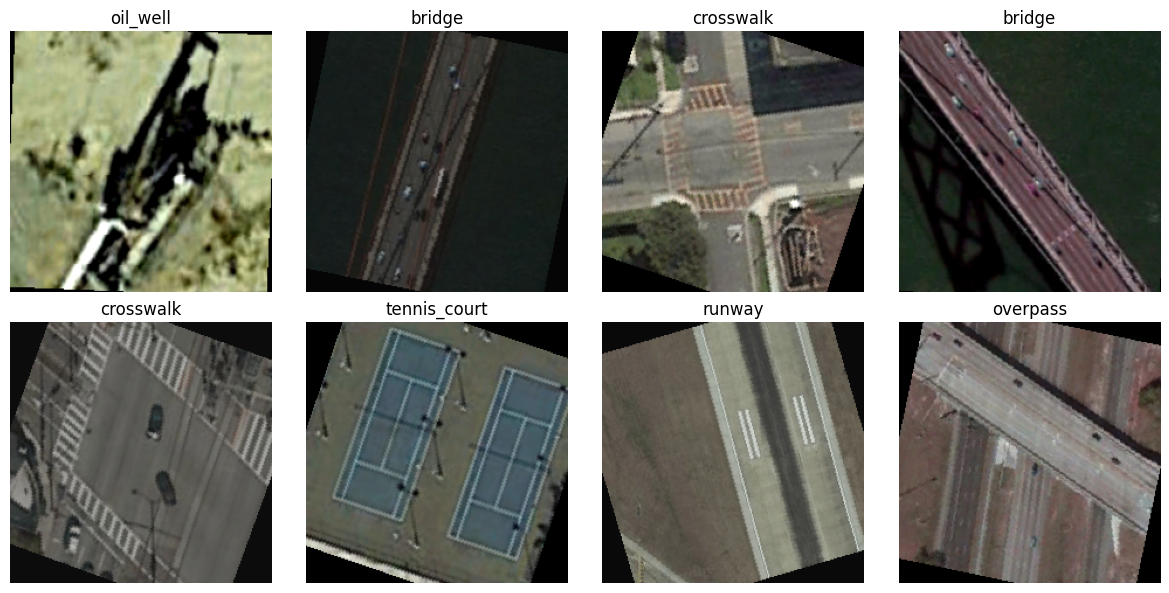

In [51]:


import matplotlib.pyplot as plt

vis_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)

images, labels = next(iter(vis_loader))

idx_to_class = {v: k for k, v in train_dataset.class_to_idx.items()}
label_names = [idx_to_class[label.item()] for label in labels]

fig, axes = plt.subplots(2, 4, figsize=(12,6))
axes = axes.flatten()

for img, label_name, ax in zip(images, label_names, axes):
    img = img.permute(1,2,0)
    img = img.numpy()
    ax.imshow(img)
    ax.set_title(label_name)
    ax.axis('off')

plt.tight_layout()
plt.show()
